## Análises bivariadas

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# dados_compras.csv e fraudes_scores.csv

df_compras = pd.read_csv("../1.data/2.processed/dados_compras.csv", parse_dates=["data_compra"])
df_scores = pd.read_csv("../1.data/2.processed/fraudes_scores.csv")

In [38]:
df_compras.columns

Index(['id_compra', 'produto', 'categoria_produto', 'valor_compra',
       'data_compra', 'dia_semana', 'hora_compra', 'pais', 'pais_agrupado',
       'entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3', 'fraude'],
      dtype='str')

In [39]:
df_compras.groupby('fraude')['valor_compra'].mean()

fraude
0    41.973326
1    72.969483
Name: valor_compra, dtype: float64

In [40]:
df_compras.groupby('fraude')['valor_compra'].sum()

fraude
0    5981199.00
1     547271.12
Name: valor_compra, dtype: float64

In [41]:
resumo_valores = df_compras.groupby('fraude')['valor_compra'].agg(['mean', 'median', 'count', 'min', 'max'])
resumo_valores

,mean,median,count,min,max
fraude,,,,,
0,41.973326,20.18,142500,0.02,3696.35
1,72.969483,25.87,7500,0.21,3424.81


| Parte | O que faz |
|---|---|
| `df_compras.groupby("fraude")` | separa em dois grupos: legítimas (0) e fraudes (1) |
| `["valor_compra"]` | escolhe a coluna do valor |
| `.agg(["count", "mean", "median", "max"])` | calcula as 4 contas da lista em cada grupo |

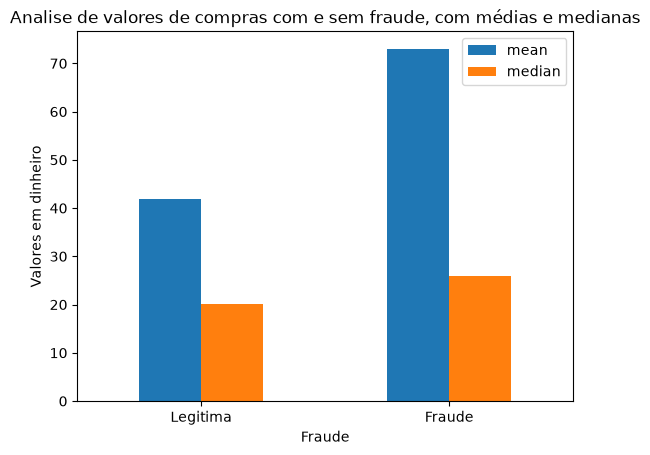

In [42]:
resumo_valores[['mean', 'median']].plot(kind='bar')
plt.title("Analise de valores de compras com e sem fraude, com médias e medianas")
plt.ylabel("Valores em dinheiro")
plt.xlabel("Fraude")
plt.xticks([0,1],['Legitima', "Fraude"], rotation=0)
plt.show()

In [43]:
df_compras.columns

Index(['id_compra', 'produto', 'categoria_produto', 'valor_compra',
       'data_compra', 'dia_semana', 'hora_compra', 'pais', 'pais_agrupado',
       'entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3', 'fraude'],
      dtype='str')

In [44]:
fraudes_valores_dias = df_compras.groupby(['fraude', 'dia_semana'])['valor_compra'].agg(['mean', 'median', 'count', 'min', 'max'])
fraudes_valores_dias

mean  median  count   min      max
fraude dia_semana                                         
0      Domingo     39.184366  19.330  18409  0.02  2366.83
       Quarta      44.370952  21.205  21166  0.09  2957.82
       Quinta      42.511826  20.740  20020  0.02  2877.62
       Segunda     42.481239  20.570  24573  0.02  3696.35
       Sexta       42.111917  20.380  17331  0.02  3181.33
       Sábado      39.563548  19.200  15461  0.03  1876.49
       Terça       42.450531  20.245  25540  0.02  3545.41
1      Domingo     64.443156  25.340    941  0.35  1545.52
       Quarta      79.207274  26.720   1005  0.59  3424.81
       Quinta      72.825571  26.740   1138  0.34  2174.06
       Segunda     73.372091  25.240   1301  0.36  2412.01
       Sexta       70.553113  25.530    938  0.23  2706.46
       Sábado      71.438497  25.870    785  0.40  2347.92
       Terça       76.462766  25.410   1392  0.21  2409.28

In [45]:
df_compras.head()

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude
0,1,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,5.64,2020-03-27 11:51:16,Sexta,11:51,BR,BR,1,0,0,0
1,3,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,339.32,2020-03-25 18:13:38,Quarta,18:13,AR,AR,1,0,0,0
2,7,"Corpinho Avulso Joseph, Josepha Ou Placa Sem Sexo",cat_5d6059e,10.56,2020-03-22 19:20:24,Domingo,19:20,BR,BR,0,0,0,0
3,10,Gamepad Joystick Para Telefono Celular Android...,cat_5d79fb9,30.48,2020-03-11 15:06:38,Quarta,15:06,AR,AR,1,0,1,0
4,11,Escova Dental Curaprox 5460 Ultra Soft Com 3 U...,cat_4744ece,14.85,2020-03-15 19:18:50,Domingo,19:18,BR,BR,1,1,1,0


In [46]:
df_compras['hora'] = df_compras['data_compra'].dt.hour
df_compras.head()

,id_compra,produto,categoria_produto,valor_compra,data_compra,dia_semana,hora_compra,pais,pais_agrupado,entrega_doc_1,entrega_doc_2,entrega_doc_3,fraude,hora
0,1,Máquininha Corta Barba Cabelo Peito Perna Pelo...,cat_8d714cd,5.64,2020-03-27 11:51:16,Sexta,11:51,BR,BR,1,0,0,0,11
1,3,Bicicleta Mountain Fire Bird Rodado 29 Alumini...,cat_e9110c5,339.32,2020-03-25 18:13:38,Quarta,18:13,AR,AR,1,0,0,0,18
2,7,"Corpinho Avulso Joseph, Josepha Ou Placa Sem Sexo",cat_5d6059e,10.56,2020-03-22 19:20:24,Domingo,19:20,BR,BR,0,0,0,0,19
3,10,Gamepad Joystick Para Telefono Celular Android...,cat_5d79fb9,30.48,2020-03-11 15:06:38,Quarta,15:06,AR,AR,1,0,1,0,15
4,11,Escova Dental Curaprox 5460 Ultra Soft Com 3 U...,cat_4744ece,14.85,2020-03-15 19:18:50,Domingo,19:18,BR,BR,1,1,1,0,19


In [49]:
fraude_hora_dia = df_compras.groupby(['dia_semana', 'hora'])['fraude'].mean().reset_index()
fraude_hora_dia

,dia_semana,hora,fraude
0,Domingo,0,0.102310
1,Domingo,1,0.107784
2,Domingo,2,0.137615
3,Domingo,3,0.125000
4,Domingo,4,0.083333
...,...,...,...
163,Terça,19,0.041898
164,Terça,20,0.052569
165,Terça,21,0.050106
166,Terça,22,0.074811


In [50]:
pivot_media_fraudes = fraude_hora_dia.pivot(index='dia_semana', columns='hora', values='fraude')
pivot_media_fraudes

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dia_semana,,,,,,,,,,,,,,,,,,,,,
Domingo,0.102310,0.107784,0.137615,0.125000,0.083333,0.088608,0.060302,0.037234,0.049624,0.047253,...,0.033579,0.045534,0.043443,0.044531,0.046875,0.042244,0.047551,0.051012,0.051195,0.106969
Quarta,0.059480,0.125000,0.206186,0.017241,0.142857,0.043716,0.034031,0.030303,0.030870,0.038515,...,0.045790,0.045706,0.053154,0.044283,0.047404,0.044944,0.047009,0.042060,0.052500,0.089130
Quinta,0.108303,0.136054,0.200000,0.128571,0.105263,0.065990,0.076294,0.042493,0.036697,0.039275,...,0.049720,0.047794,0.046404,0.051181,0.041142,0.060531,0.059875,0.062753,0.078947,0.116424
Segunda,0.108359,0.128655,0.172727,0.190476,0.092784,0.080000,0.038168,0.049223,0.041291,0.040446,...,0.044626,0.049479,0.040050,0.043943,0.040792,0.045169,0.053644,0.046864,0.074257,0.096618
Sexta,0.137255,0.188034,0.197368,0.274194,0.164557,0.086957,0.039634,0.038270,0.048008,0.038071,...,0.047538,0.051064,0.047743,0.044400,0.062500,0.047151,0.041195,0.057178,0.061329,0.075521
Sábado,0.100000,0.120567,0.128571,0.176471,0.093750,0.101852,0.048309,0.037647,0.061654,0.028662,...,0.042135,0.044651,0.048467,0.050746,0.037755,0.046201,0.062645,0.052963,0.057451,0.058537
Terça,0.085960,0.136612,0.164835,0.090909,0.105882,0.059783,0.044601,0.036991,0.044408,0.039673,...,0.052951,0.052887,0.063329,0.046296,0.048420,0.041898,0.052569,0.050106,0.074811,0.075949


In [51]:
ordem_dias = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]
pivot_media_fraudes = pivot_media_fraudes.loc[ordem_dias]

In [52]:
pivot_media_fraudes

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
dia_semana,,,,,,,,,,,,,,,,,,,,,
Segunda,0.108359,0.128655,0.172727,0.190476,0.092784,0.080000,0.038168,0.049223,0.041291,0.040446,...,0.044626,0.049479,0.040050,0.043943,0.040792,0.045169,0.053644,0.046864,0.074257,0.096618
Terça,0.085960,0.136612,0.164835,0.090909,0.105882,0.059783,0.044601,0.036991,0.044408,0.039673,...,0.052951,0.052887,0.063329,0.046296,0.048420,0.041898,0.052569,0.050106,0.074811,0.075949
Quarta,0.059480,0.125000,0.206186,0.017241,0.142857,0.043716,0.034031,0.030303,0.030870,0.038515,...,0.045790,0.045706,0.053154,0.044283,0.047404,0.044944,0.047009,0.042060,0.052500,0.089130
Quinta,0.108303,0.136054,0.200000,0.128571,0.105263,0.065990,0.076294,0.042493,0.036697,0.039275,...,0.049720,0.047794,0.046404,0.051181,0.041142,0.060531,0.059875,0.062753,0.078947,0.116424
Sexta,0.137255,0.188034,0.197368,0.274194,0.164557,0.086957,0.039634,0.038270,0.048008,0.038071,...,0.047538,0.051064,0.047743,0.044400,0.062500,0.047151,0.041195,0.057178,0.061329,0.075521
Sábado,0.100000,0.120567,0.128571,0.176471,0.093750,0.101852,0.048309,0.037647,0.061654,0.028662,...,0.042135,0.044651,0.048467,0.050746,0.037755,0.046201,0.062645,0.052963,0.057451,0.058537
Domingo,0.102310,0.107784,0.137615,0.125000,0.083333,0.088608,0.060302,0.037234,0.049624,0.047253,...,0.033579,0.045534,0.043443,0.044531,0.046875,0.042244,0.047551,0.051012,0.051195,0.106969


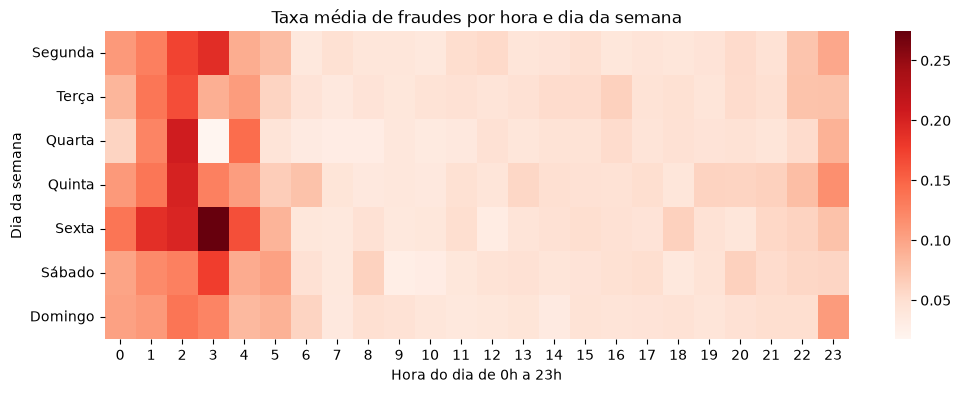

In [56]:
plt.figure(figsize=(12,4)) # o tamanho é em polegadas
sns.heatmap(pivot_media_fraudes, cmap='Reds')
plt.title('Taxa média de fraudes por hora e dia da semana')
plt.ylabel('Dia da semana')
plt.xlabel("Hora do dia de 0h a 23h")
plt.show()

### Stack e pivot 

pivot == unstack

stack é o caminho contrário do pivot table.

In [59]:
pivot_media_fraudes.stack().reset_index()

,dia_semana,hora,0
0,Segunda,0,0.108359
1,Segunda,1,0.128655
2,Segunda,2,0.172727
3,Segunda,3,0.190476
4,Segunda,4,0.092784
...,...,...,...
163,Domingo,19,0.042244
164,Domingo,20,0.047551
165,Domingo,21,0.051012
166,Domingo,22,0.051195


In [63]:
df_taxa = pivot_media_fraudes.stack().reset_index(name='taxa_fraude')
df_taxa['taxa_fraude'] = df_taxa['taxa_fraude'] * 100  
df_taxa

,dia_semana,hora,taxa_fraude
0,Segunda,0,10.835913
1,Segunda,1,12.865497
2,Segunda,2,17.272727
3,Segunda,3,19.047619
4,Segunda,4,9.278351
...,...,...,...
163,Domingo,19,4.224377
164,Domingo,20,4.755145
165,Domingo,21,5.101215
166,Domingo,22,5.119454


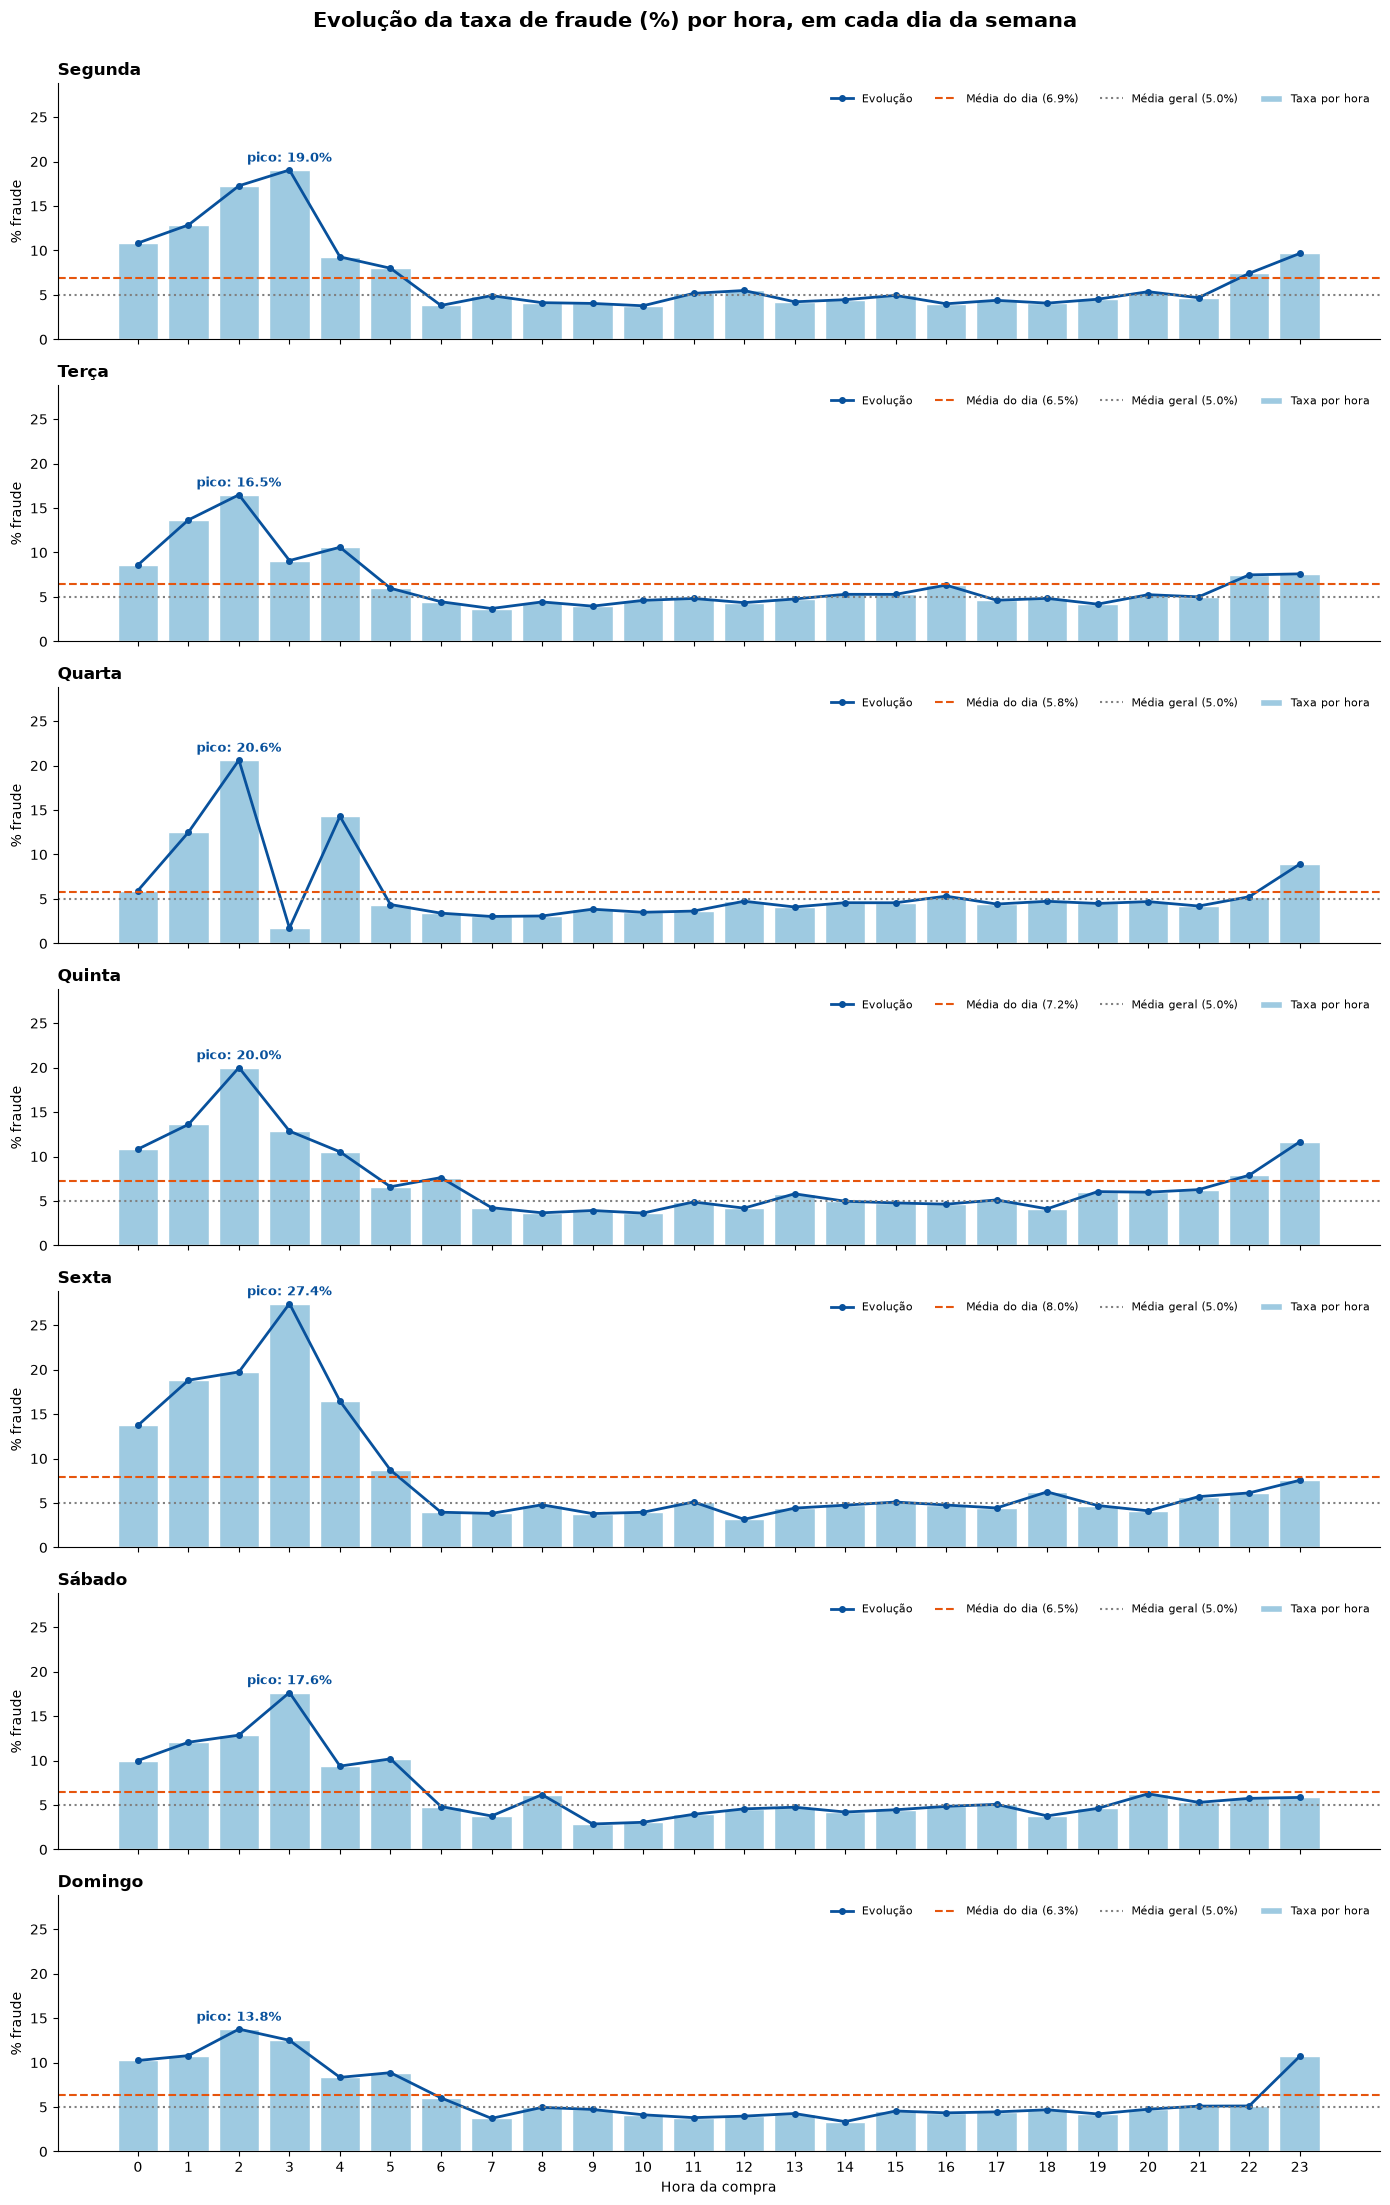

In [66]:
# Formato longo: dia_semana | hora_compra | taxa_fraude (%)
df_taxa = pivot_media_fraudes.stack().reset_index(name='taxa_fraude')
df_taxa['taxa_fraude'] = df_taxa['taxa_fraude'] * 100  # média de 0/1 -> %

#ordem_dias = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
taxa_geral = df_compras['fraude'].mean() * 100

fig, axes = plt.subplots(7, 1, figsize=(14, 22), sharex=True, sharey=True)

for ax, dia in zip(axes, ordem_dias):
    dados_dia = df_taxa[df_taxa['dia_semana'] == dia].sort_values('hora')
    horas = dados_dia['hora']
    taxas = dados_dia['taxa_fraude']

    # Barras: taxa de fraude em cada hora
    ax.bar(horas, taxas, color='#9ecae1', edgecolor='white', label='Taxa por hora')

    # Linha: a "história" da evolução ao longo do dia
    ax.plot(horas, taxas, color='#08519c', marker='o', markersize=4, linewidth=2,
            label='Evolução')

    # Referências horizontais: média do dia e média geral
    media_dia = taxas.mean()
    ax.axhline(media_dia, color='#e6550d', linestyle='--', linewidth=1.5,
               label=f'Média do dia ({media_dia:.1f}%)')
    ax.axhline(taxa_geral, color='gray', linestyle=':', linewidth=1.5,
               label=f'Média geral ({taxa_geral:.1f}%)')

    # Destaca o pico do dia
    hora_pico = horas.loc[taxas.idxmax()]
    ax.annotate(f'pico: {taxas.max():.1f}%', xy=(hora_pico, taxas.max()),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=9,
                color='#08519c', fontweight='bold')

    ax.set_title(dia, loc='left', fontweight='bold')
    ax.set_ylabel('% fraude')
    ax.legend(loc='upper right', fontsize=8, ncol=4, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Hora da compra')
axes[-1].set_xticks(range(0, 24))
fig.suptitle('Evolução da taxa de fraude (%) por hora, em cada dia da semana',
             fontsize=15, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


In [67]:
df_compras.columns

Index(['id_compra', 'produto', 'categoria_produto', 'valor_compra',
       'data_compra', 'dia_semana', 'hora_compra', 'pais', 'pais_agrupado',
       'entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3', 'fraude', 'hora'],
      dtype='str')

In [68]:
lista_documentos = ['entrega_doc_1', 'entrega_doc_2', 'entrega_doc_3']

fraudes_docs = df_compras.groupby('fraude')[lista_documentos].mean().reset_index()
fraudes_docs

,fraude,entrega_doc_1,entrega_doc_2,entrega_doc_3
0,0,0.913775,0.158154,0.566372
1,1,0.685333,0.207200,0.322800


In [70]:
## melt
fraudes_docs_melt = fraudes_docs.melt(id_vars='fraude', var_name='documentos', value_name='taxa_entrega')
fraudes_docs_melt

,fraude,documentos,taxa_entrega
0,0,entrega_doc_1,0.913775
1,1,entrega_doc_1,0.685333
2,0,entrega_doc_2,0.158154
3,1,entrega_doc_2,0.207200
4,0,entrega_doc_3,0.566372
5,1,entrega_doc_3,0.322800


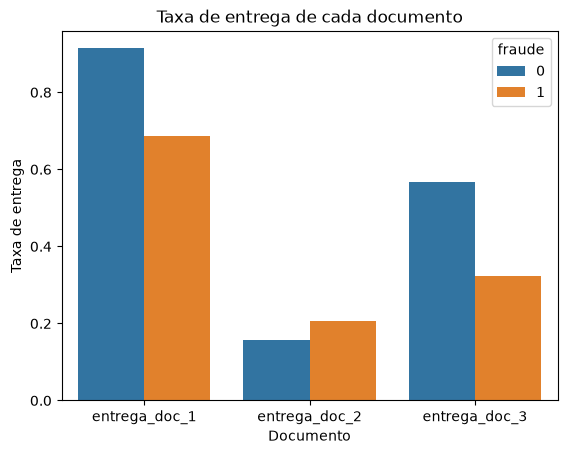

In [73]:
sns.barplot(data=fraudes_docs_melt, x='documentos', y='taxa_entrega', hue='fraude')
plt.title("Taxa de entrega de cada documento")
plt.xlabel("Documento")
plt.ylabel("Taxa de entrega")
plt.show()

In [74]:
df_scores.columns

Index(['id_compra', 'score_1', 'score_2', 'score_3', 'score_4', 'score_5',
       'score_6', 'score_7', 'score_8', 'score_9', 'score_10',
       'score_fraude_modelo', 'fraude'],
      dtype='str')

In [76]:
lista_scores = [ 'score_1', 'score_2', 'score_3', 'score_4', 'score_5',
       'score_6', 'score_7', 'score_8', 'score_9', 'score_10',
       'score_fraude_modelo', 'fraude']

scores_corr = df_scores[lista_scores].corr()
scores_corr

,score_1,score_2,score_3,score_4,score_5,score_6,score_7,score_8,score_9,score_10,score_fraude_modelo,fraude
score_1,1.000000,0.059202,-0.172649,0.008139,0.013226,-0.005110,0.044487,-0.001389,-0.021596,0.002536,-0.116879,-0.059681
score_2,0.059202,1.000000,0.079398,0.000978,-0.013308,-0.021626,-0.043632,-0.002555,-0.034963,-0.025714,-0.026813,0.037846
score_3,-0.172649,0.079398,1.000000,0.001699,-0.010278,-0.002797,0.019132,0.000116,-0.019129,-0.001580,0.019058,0.029802
score_4,0.008139,0.000978,0.001699,1.000000,-0.001546,0.007577,0.020601,0.002095,0.062473,0.588182,-0.128361,-0.077771
score_5,0.013226,-0.013308,-0.010278,-0.001546,1.000000,0.010515,0.002831,-0.000344,-0.004349,-0.003405,-0.000289,-0.002261
score_6,-0.005110,-0.021626,-0.002797,0.007577,0.010515,1.000000,-0.000668,-0.001441,0.069056,0.023084,-0.019727,-0.010488
score_7,0.044487,-0.043632,0.019132,0.020601,0.002831,-0.000668,1.000000,-0.003904,-0.002158,0.016566,-0.020393,-0.034864
score_8,-0.001389,-0.002555,0.000116,0.002095,-0.000344,-0.001441,-0.003904,1.000000,0.001947,0.001324,0.001370,0.002395
score_9,-0.021596,-0.034963,-0.019129,0.062473,-0.004349,0.069056,-0.002158,0.001947,1.000000,0.187104,-0.197708,-0.117019
score_10,0.002536,-0.025714,-0.001580,0.588182,-0.003405,0.023084,0.016566,0.001324,0.187104,1.000000,-0.151642,-0.093357


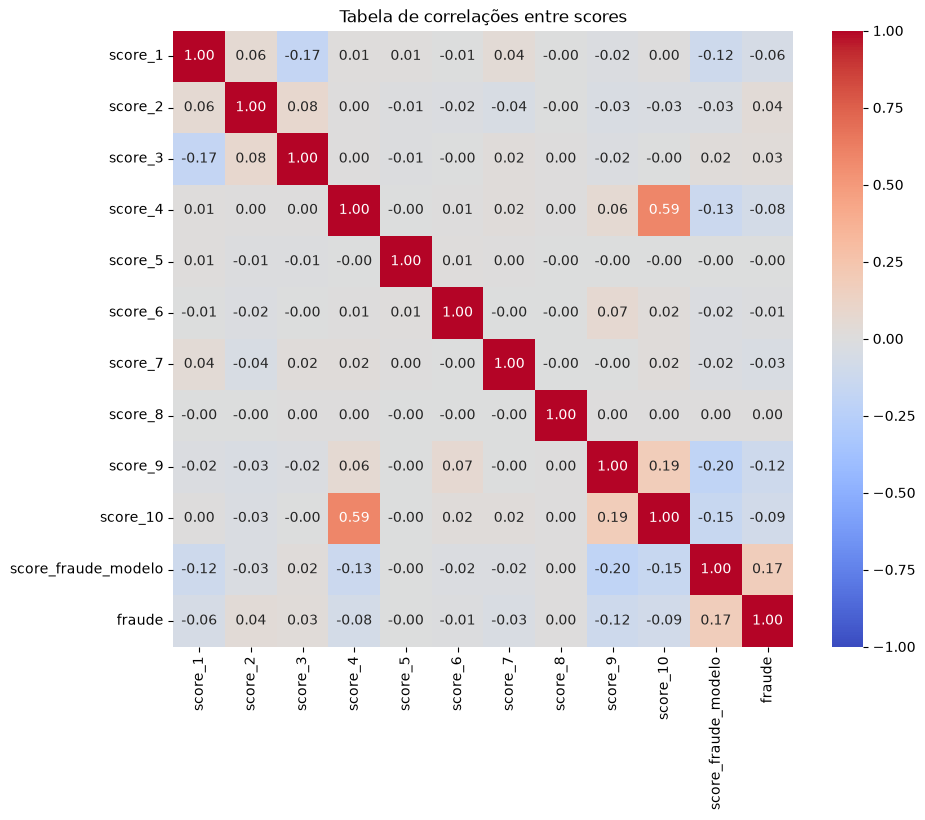

In [78]:
plt.figure(figsize=(10,8))
sns.heatmap(scores_corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm") ## ".2f" casas decimais que teremos
plt.title('Tabela de correlações entre scores')
plt.show()